# Modelo B (MobileNet-style): reconocimiento de comandos de voz

Notebook autocontenido y mínimo con todo el flujo del Modelo B:

1. Datos y **split oficial** de Speech Commands v0.02 (por hablante)
2. Cache de mel-espectrogramas (normalización calculada **solo con train**)
3. Aumento de datos: time shifting + noise injection (audio) y SpecAugment (espectrograma)
4. Modelo B escrito a mano con `torch.nn` + diagrama
5. 6 entrenamientos (3 base + 3 aumentados) con registro en Weights & Biases
6. Resultados, selección del mejor modelo por **val F1** y reporte en test
7. Exportación a ONNX con verificación de paridad + `preprocessing.json` para la app móvil

**Uso rápido:** pon `QUICK_RUN = True` para validar todo el flujo en pocos minutos. Cada run guarda su `result.json`, así que puedes ejecutar base y aumentado en sesiones distintas.

## 0. Configuración

In [16]:
import os, json, math, random, shutil, ssl, tarfile, urllib.request, wave, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import wandb
import torchaudio
import torch.nn.functional as F
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset

# ---------- Configuración (editable) ----------
DATA_DIR      = Path(os.environ.get("DATA_DIR", "./data/speech_commands_10"))  # carpeta con yes/, no/, ... (o el dataset completo)
WORK_DIR      = Path(os.environ.get("WORK_DIR", "./notebook_outputs"))
QUICK_RUN     = os.environ.get("QUICK_RUN", "0") == "1"      # True: prueba rápida (pocos datos y épocas)
WANDB_MODE    = WANDB_MODE = "online"     # "online" | "offline" | "disabled"
WANDB_PROJECT = "speech-commands-10"
SEED          = 42
EPOCHS        = 2 if QUICK_RUN else 20
PATIENCE      = 5            # early stopping sobre val F1
NUM_WORKERS   = 0
PIN_MEMORY    = torch.cuda.is_available()
AMP_ENABLED   = torch.cuda.is_available()
DETERMINISTIC = os.environ.get("DETERMINISTIC", "0") == "1"
SKIP_FINISHED = False         # no repetir runs que ya tienen result.json
REBUILD_CACHE = False
INSECURE_DOWNLOAD = True    # solo en una red de confianza si hay error de certificado TLS

# ---------- Constantes del problema ----------
SAMPLE_RATE, CLIP_SAMPLES, N_MELS = 16_000, 16_000, 64
LABELS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABEL_TO_INDEX = {l: i for i, l in enumerate(LABELS)}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORK_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = DETERMINISTIC
    torch.backends.cudnn.benchmark = DEVICE.type == "cuda" and not DETERMINISTIC

set_seed(SEED)
print(f"device={DEVICE} | torch={torch.__version__} | torchaudio={torchaudio.__version__} | QUICK_RUN={QUICK_RUN}")
print(f"workers={NUM_WORKERS} | pin_memory={PIN_MEMORY} | amp={AMP_ENABLED} | deterministic={DETERMINISTIC}")

device=cuda | torch=2.14.1+cu126 | torchaudio=2.11.0+cu126 | QUICK_RUN=False
workers=0 | pin_memory=True | amp=True | deterministic=False


In [17]:
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)
print("GPU detectadas:", torch.cuda.device_count())

CUDA disponible: True
CUDA de PyTorch: 12.6
GPU detectadas: 1


## 1. Datos

Si `DATA_DIR` no contiene las 10 clases, se descarga Speech Commands v0.02 (~2.3 GB). El notebook trabaja directamente sobre `DATA_DIR`: solo lee las 10 clases, `_background_noise_` y las listas oficiales `validation_list.txt` / `testing_list.txt`. Sirve tanto la carpeta filtrada (`speech_commands_10`) como el dataset completo.

> En Colab: monta Drive y apunta `DATA_DIR` y `WORK_DIR` a una carpeta de Drive para no perder el cache ni los resultados.

In [18]:
DATASET_URL = "https://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

def download_dataset(dest: Path, insecure: bool = False) -> None:
    dest.mkdir(parents=True, exist_ok=True)
    archive = dest / "speech_commands_v0.02.tar.gz"
    if not archive.exists():
        ctx = ssl._create_unverified_context() if insecure else ssl.create_default_context()
        tmp = archive.with_suffix(".part")
        with urllib.request.urlopen(DATASET_URL, context=ctx) as resp, tmp.open("wb") as out:
            shutil.copyfileobj(resp, out)
        tmp.replace(archive)
    with tarfile.open(archive, "r:gz") as tar:
        tar.extractall(dest)

if not all((DATA_DIR / c).is_dir() for c in LABELS):
    print("Descargando Speech Commands v0.02 ...")
    download_dataset(DATA_DIR, INSECURE_DOWNLOAD)

for f in ("validation_list.txt", "testing_list.txt"):
    assert (DATA_DIR / f).exists(), f"Falta {DATA_DIR / f}"
print({c: len(list((DATA_DIR / c).glob('*.wav'))) for c in LABELS})

{'yes': 4044, 'no': 3941, 'up': 3723, 'down': 3917, 'left': 3801, 'right': 3778, 'on': 3845, 'off': 3745, 'stop': 3872, 'go': 3880}


## 2. Preprocesamiento y cache

- WAV → mono, 16 kHz, 1 s (recorte o relleno con ceros)
- `MelSpectrogram(n_fft=400, win_length=400, hop_length=160, n_mels=64)` → dB (`amin=1e-10`) → tensor `(1, 64, 101)`
- Normalización global `(x - mean) / std` con media y desviación calculadas **solo sobre train** (sin fuga de val/test)
- Split **oficial** de Speech Commands (separa por hablante). Todo lo que no está en las listas de val/test es train.
- Se guardan en el cache los espectrogramas normalizados (float16) y las formas de onda (int16), estas últimas para el aumento en el dominio del audio.

In [19]:
def load_wav(path) -> Tensor:
    # Lee un WAV PCM con la librería estándar (evita la dependencia de torchcodec). Devuelve (1, T) en [-1, 1].
    with wave.open(str(path), "rb") as w:
        sr, ch, width = w.getframerate(), w.getnchannels(), w.getsampwidth()
        raw = w.readframes(w.getnframes())
    if width != 2:
        raise ValueError(f"Solo se soporta PCM de 16 bits: {path}")
    x = torch.from_numpy(np.frombuffer(raw, dtype="<i2").astype(np.float32) / 32768.0)
    x = x.view(-1, ch).mean(dim=1, keepdim=True).T.contiguous()
    if sr != SAMPLE_RATE:
        x = torchaudio.functional.resample(x, sr, SAMPLE_RATE)
    return x

def fix_length(x: Tensor) -> Tensor:
    if x.shape[1] >= CLIP_SAMPLES:
        return x[:, :CLIP_SAMPLES]
    return F.pad(x, (0, CLIP_SAMPLES - x.shape[1]))

def make_mel() -> torchaudio.transforms.MelSpectrogram:
    return torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_mels=N_MELS, n_fft=400, win_length=400, hop_length=160)

def to_db(mel: Tensor) -> Tensor:
    return torchaudio.functional.amplitude_to_DB(mel, multiplier=10.0, amin=1e-10, db_multiplier=0.0)

def official_splits(data_dir: Path) -> dict:
    out = {}
    for split, fname in (("val", "validation_list.txt"), ("test", "testing_list.txt")):
        for line in (data_dir / fname).read_text(encoding="utf-8").splitlines():
            if line.strip():
                out[line.strip()] = split
    return out

def build_cache(data_dir: Path, cache_path: Path) -> None:
    split_map = official_splits(data_dir)
    waves, labels, splits, paths = [], [], [], []
    for label in LABELS:
        for p in sorted((data_dir / label).glob("*.wav")):
            w = fix_length(load_wav(p)).squeeze(0)
            waves.append((w * 32768.0).round().clamp(-32768, 32767).to(torch.int16))
            rel = p.relative_to(data_dir).as_posix()
            labels.append(LABEL_TO_INDEX[label]); splits.append(split_map.get(rel, "train")); paths.append(rel)
        print(f"  {label}: ok", end="")
    print()
    waves = torch.stack(waves)

    mel, chunks = make_mel(), []
    for i in range(0, len(waves), 512):
        chunks.append(to_db(mel(waves[i:i + 512].float() / 32768.0)))
    raw_db = torch.cat(chunks)                                    # (N, 64, 101)

    train_mask = torch.tensor([s == "train" for s in splits])
    mean = raw_db[train_mask].mean()
    std = raw_db[train_mask].std().clamp_min(1e-6)                 # solo train
    specs = ((raw_db - mean) / std).to(torch.float16)

    torch.save({"specs": specs, "waves": waves, "labels": torch.tensor(labels), "splits": splits, "paths": paths,
                "mean": float(mean), "std": float(std), "n_mels": N_MELS, "sample_rate": SAMPLE_RATE}, cache_path)

CACHE_PATH = WORK_DIR / "cache.pt"
if REBUILD_CACHE or not CACHE_PATH.exists():
    print("Construyendo cache ...")
    build_cache(DATA_DIR, CACHE_PATH)
CACHE = torch.load(CACHE_PATH)
print(f"clips={len(CACHE['labels'])} | specs={tuple(CACHE['specs'].shape)} | mean={CACHE['mean']:.3f} std={CACHE['std']:.3f}")

clips=38546 | specs=(38546, 64, 101) | mean=-33.879 std=23.382


### Split oficial y comprobaciones

In [20]:
def subsample(idx, n, seed=SEED):
    if n is None or len(idx) <= n:
        return idx
    return sorted(np.random.RandomState(seed).choice(idx, n, replace=False).tolist())

_s = np.array(CACHE["splits"])
TRAIN_IDX, VAL_IDX, TEST_IDX = (np.where(_s == k)[0].tolist() for k in ("train", "val", "test"))
if QUICK_RUN:                                         # muestra pequeña y aleatoria (no los primeros N, que serían una sola clase)
    TRAIN_IDX, VAL_IDX, TEST_IDX = subsample(TRAIN_IDX, 1500), subsample(VAL_IDX, 500), subsample(TEST_IDX, 500)

def speaker(path: str) -> str:
    return Path(path).name.split("_nohash_")[0]

speakers = {n: {speaker(CACHE["paths"][i]) for i in idx} for n, idx in (("train", TRAIN_IDX), ("val", VAL_IDX), ("test", TEST_IDX))}
assert not (speakers["train"] & speakers["val"]) and not (speakers["train"] & speakers["test"]) and not (speakers["val"] & speakers["test"]), \
    "Hay hablantes repetidos entre splits"
print(f"train={len(TRAIN_IDX)} val={len(VAL_IDX)} test={len(TEST_IDX)} | hablantes: " + ", ".join(f"{k}={len(v)}" for k, v in speakers.items()))
print("Sin hablantes compartidos entre train/val/test ✔")

train=30769 val=3703 test=4074 | hablantes: train=2008, val=245, test=239
Sin hablantes compartidos entre train/val/test ✔


## 3. Aumento de datos

| Dominio | Técnica | Parámetros |
|---|---|---|
| Audio | Time shifting | ±100 ms, relleno con ceros |
| Audio | Noise injection (`_background_noise_`) | SNR aleatorio 5–20 dB |
| Espectrograma | SpecAugment (Park et al., 2019) | F=8, T=16, 2 máscaras (relleno con la media) |

Solo se aplica a **train**; validación y test usan siempre los espectrogramas limpios del cache. Pitch shifting y time stretching no se usan (coste de CPU; SpecAugment es el método principal).

In [21]:
class SpecAugment(nn.Module):
    # Máscaras de frecuencia y tiempo sobre el espectrograma normalizado (Park et al., 2019).
    def __init__(self, freq_mask_param=8, time_mask_param=16, num_masks=2):
        super().__init__()
        self.f, self.t, self.n = freq_mask_param, time_mask_param, num_masks

    def forward(self, spec: Tensor) -> Tensor:
        out, fill = spec.clone(), float(spec.mean())
        n_freq, n_time = spec.shape[-2], spec.shape[-1]
        for _ in range(self.n):
            fw = int(torch.randint(min(self.f, n_freq) + 1, ()))
            tw = int(torch.randint(min(self.t, n_time) + 1, ()))
            if fw:
                f0 = int(torch.randint(n_freq - fw + 1, ()))
                out[..., f0:f0 + fw, :] = fill
            if tw:
                t0 = int(torch.randint(n_time - tw + 1, ()))
                out[..., :, t0:t0 + tw] = fill
        return out

def load_noises(data_dir: Path):
    files = sorted((data_dir / "_background_noise_").glob("*.wav"))
    if not files:
        raise FileNotFoundError(f"No hay .wav en {data_dir / '_background_noise_'}")
    noises = []
    for f in files:
        x = load_wav(f)
        if x.shape[1] < CLIP_SAMPLES:
            x = x.repeat(1, math.ceil(CLIP_SAMPLES / x.shape[1]))
        noises.append(x)
    return noises

class CachedSpecs(Dataset):
    # Espectrogramas limpios del cache -> (1, 64, 101)
    def __init__(self, cache, indices):
        self.cache, self.indices = cache, list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]
        return self.cache["specs"][j].float().unsqueeze(0), int(self.cache["labels"][j])

class SpecAugmentOnly(Dataset):
    # Ablación: solo SpecAugment sobre los espectrogramas del cache (sin aumento en el audio)
    def __init__(self, cache, indices):
        self.base, self.spec_aug = CachedSpecs(cache, indices), SpecAugment()
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]
        return self.spec_aug(x), y

class AugmentedTrainSet(Dataset):
    # waveform -> time shift -> ruido de fondo -> mel -> dB -> normalización -> SpecAugment
    def __init__(self, cache, indices, noises, p_augment=1.0, max_shift_ms=100.0, snr_db=(5.0, 20.0)):
        self.cache, self.indices, self.noises = cache, list(indices), noises
        self.p, self.snr = p_augment, snr_db
        self.max_shift = int(SAMPLE_RATE * max_shift_ms / 1000)
        self.mel, self.spec_aug = make_mel(), SpecAugment()
        self.mean, self.std = cache["mean"], cache["std"]

    def __len__(self):
        return len(self.indices)

    def time_shift(self, wav):
        s = int(torch.randint(-self.max_shift, self.max_shift + 1, ()))
        out = torch.zeros_like(wav)
        if s >= 0:
            out[:, s:] = wav[:, :wav.shape[1] - s]
        else:
            out[:, :s] = wav[:, -s:]
        return out

    def add_noise(self, wav):
        noise = self.noises[int(torch.randint(len(self.noises), ()))]
        start = int(torch.randint(noise.shape[1] - CLIP_SAMPLES + 1, ()))
        noise = noise[:, start:start + CLIP_SAMPLES]
        snr = float(torch.empty(()).uniform_(*self.snr))
        sig_rms = wav.pow(2).mean().sqrt()
        noise_rms = noise.pow(2).mean().sqrt().clamp_min(1e-8)
        return wav + noise * sig_rms / (10 ** (snr / 20) * noise_rms)

    def __getitem__(self, i):
        j = self.indices[i]
        label = int(self.cache["labels"][j])
        if torch.rand(()) > self.p:                      # p_augment < 1 deja algunos ejemplos limpios
            return self.cache["specs"][j].float().unsqueeze(0), label
        wav = self.cache["waves"][j].float().div(32768.0).unsqueeze(0)
        wav = self.add_noise(self.time_shift(wav))
        spec = (to_db(self.mel(wav)) - self.mean) / self.std
        return self.spec_aug(spec), label

NOISES = load_noises(DATA_DIR)
print(f"{len(NOISES)} archivos de ruido de fondo cargados")

6 archivos de ruido de fondo cargados


Ejemplo visual: espectrograma limpio vs. aumentado de la misma muestra.

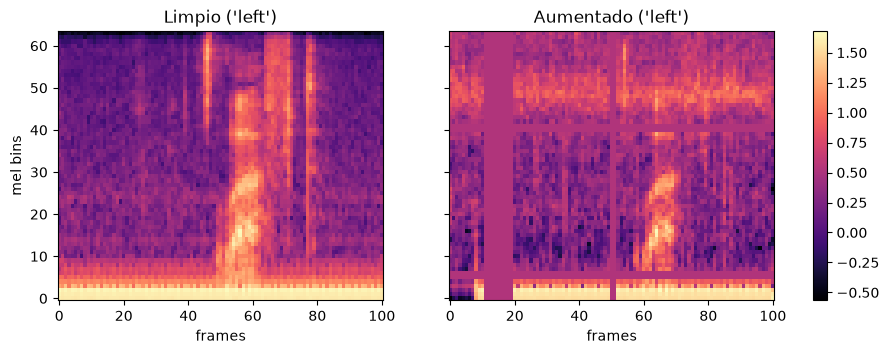

In [22]:
set_seed(SEED)
j = TRAIN_IDX[len(TRAIN_IDX) // 2]
clean, label = CachedSpecs(CACHE, [j])[0]
aug, _ = AugmentedTrainSet(CACHE, [j], NOISES)[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, spec, title in zip(axes, (clean, aug), ("Limpio", "Aumentado")):
    im = ax.imshow(spec[0].numpy(), origin="lower", aspect="auto", cmap="magma"); ax.set_title(f"{title} ('{LABELS[label]}')"); ax.set_xlabel("frames")
axes[0].set_ylabel("mel bins"); plt.colorbar(im, ax=axes, fraction=0.025); plt.show()

## 4. Modelo B: MobileNet-V1-style (hecho a mano con `torch.nn`)

Entrada `1×64×101`. Stem `Conv3×3` (1→32) seguido de 3 bloques *depthwise-separable* (`DW 3×3 + BN + ReLU` → `PW 1×1 + BN + ReLU`) con anchos 64→128→128 y strides 2, 2, 1. Después: global average pooling, dropout y capa lineal a 10 clases.

- **Depthwise separable:** reduce los MACs frente a una convolución estándar con casi la misma capacidad expresiva, ideal para móvil.
- **ReLU:** barata de ejecutar en ONNX Runtime Mobile y evita saturación.
- **GAP + dropout:** pocos parámetros en la cabeza y menos riesgo de sobreajuste.
- **`width_mult`:** escala los anchos para el compromiso precisión/eficiencia.

In [23]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.dw_bn = nn.BatchNorm2d(in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.pw_bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act(self.dw_bn(self.depthwise(x)))
        return self.act(self.pw_bn(self.pointwise(x)))

class MobileNetStyleCNN(nn.Module):
    def __init__(self, num_classes=10, width_mult=1.0, channels=(32, 64, 128, 128), strides=(1, 2, 2, 1), dropout=0.2):
        super().__init__()
        ch = [max(8, int(c * width_mult)) for c in channels]
        self.stem = nn.Sequential(nn.Conv2d(1, ch[0], 3, stride=strides[0], padding=1, bias=False),
                                  nn.BatchNorm2d(ch[0]), nn.ReLU(inplace=True))
        blocks, in_ch = [], ch[0]
        for out_ch, s in zip(ch[1:], strides[1:]):
            blocks.append(DepthwiseSeparableConv(in_ch, out_ch, s)); in_ch = out_ch
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        x = self.pool(self.features(self.stem(x)))
        return self.classifier(self.dropout(torch.flatten(x, 1)))

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def estimate_macs(self, input_shape=(1, 64, 101)) -> int:
        macs = 0
        def hook(m, inp, out):
            nonlocal macs
            if isinstance(m, nn.Conv2d):
                macs += out.shape[0] * out.shape[2] * out.shape[3] * m.out_channels * (m.in_channels // m.groups) * m.kernel_size[0] * m.kernel_size[1]
            elif isinstance(m, nn.Linear):
                macs += inp[0].shape[0] * m.in_features * m.out_features
        hs = [m.register_forward_hook(hook) for m in self.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]
        was_training = self.training; self.eval()
        with torch.no_grad():
            self(torch.zeros(1, *input_shape, device=next(self.parameters()).device))
        if was_training: self.train()
        for h in hs: h.remove()
        return macs

m = MobileNetStyleCNN()
print(f"parámetros={m.count_parameters():,} | MACs≈{m.estimate_macs():,}")

parámetros=31,370 | MACs≈16,617,728


### Diagrama de arquitectura (generado a partir del modelo)

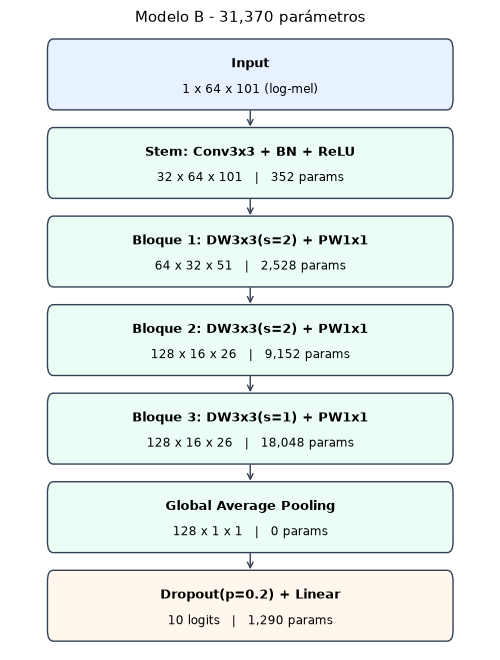

In [9]:
from matplotlib.patches import FancyBboxPatch

def draw_architecture(model: nn.Module, path: Path) -> None:
    mods = dict(model.named_modules())
    names = ["stem"] + [f"features.{i}" for i in range(len(model.features))] + ["pool", "classifier"]
    shapes = {}
    hooks = [mods[n].register_forward_hook(lambda mod, i, o, n=n: shapes.__setitem__(n, tuple(o.shape[1:]))) for n in names]
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, 1, 64, 101))
    for h in hooks: h.remove()

    nparams = lambda mod: sum(p.numel() for p in mod.parameters())
    boxes = [("Input", "1 x 64 x 101 (log-mel)", None)]
    boxes.append(("Stem: Conv3x3 + BN + ReLU", " x ".join(map(str, shapes["stem"])), nparams(mods["stem"])))
    for i in range(len(model.features)):
        blk = mods[f"features.{i}"]
        boxes.append((f"Bloque {i+1}: DW3x3(s={blk.depthwise.stride[0]}) + PW1x1", " x ".join(map(str, shapes[f"features.{i}"])), nparams(blk)))
    boxes.append(("Global Average Pooling", " x ".join(map(str, shapes["pool"])), 0))
    boxes.append((f"Dropout(p={model.dropout.p}) + Linear", f"{shapes['classifier'][0]} logits", nparams(mods["classifier"])))

    fig, ax = plt.subplots(figsize=(6.2, 1.15 * len(boxes)))
    ax.set_xlim(0, 10); ax.set_ylim(0, len(boxes)); ax.axis("off")
    for k, (title, shape, p) in enumerate(boxes):
        y = len(boxes) - k - 1
        ax.add_patch(FancyBboxPatch((0.8, y + 0.12), 8.4, 0.76, boxstyle="round,pad=0.02,rounding_size=0.12", fc="#e8f1ff" if k == 0 else "#ecfdf5" if k < len(boxes) - 1 else "#fff7ed", ec="#334155"))
        ax.text(5, y + 0.62, title, ha="center", va="center", fontsize=9.5, fontweight="bold")
        ax.text(5, y + 0.33, shape + ("" if p is None else f"   |   {p:,} params"), ha="center", va="center", fontsize=8.5)
        if k < len(boxes) - 1:
            ax.annotate("", xy=(5, y - 0.12), xytext=(5, y + 0.12), arrowprops=dict(arrowstyle="->", color="#334155"))
    ax.set_title(f"Modelo B - {nparams(model):,} parámetros", fontsize=11)
    fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()

draw_architecture(MobileNetStyleCNN(), WORK_DIR / "model_b_architecture.png")

## 5. Entrenamiento

- Pérdida `CrossEntropyLoss`, optimizador `Adam` (con `weight_decay`), scheduler `CosineAnnealingLR`, early stopping sobre **val F1**.
- Se guarda el checkpoint con mejor **val F1**; el **test se evalúa una sola vez** al final con ese checkpoint.
- Para vigilar over/underfitting se registra la métrica de train en dos versiones: durante el entrenamiento (con dropout y aumento) y **`train_clean`** (subconjunto fijo de train, sin aumento y en modo `eval`). El gap `train_clean_acc − val_acc` es el indicador usado.
- Todo se registra en W&B (`WANDB_MODE`).

In [24]:
def confusion_matrix(preds: Tensor, labels: Tensor, n: int = len(LABELS)) -> Tensor:
    return torch.bincount(labels * n + preds, minlength=n * n).view(n, n)

def f1_per_class(cm: Tensor) -> Tensor:
    tp = cm.diag().float(); fp = cm.sum(0).float() - tp; fn = cm.sum(1).float() - tp
    den = 2 * tp + fp + fn
    return torch.where(den > 0, 2 * tp / den, torch.zeros_like(den))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, ps, ls = 0.0, [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=PIN_MEMORY)
        y = y.to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            out = model(x)
            loss = criterion(out, y)
        total += loss.item() * x.size(0)
        ps.append(out.argmax(1).cpu()); ls.append(y.cpu())
    preds, labels = torch.cat(ps), torch.cat(ls)
    cm = confusion_matrix(preds, labels); f1c = f1_per_class(cm)
    return {"loss": total / len(labels), "acc": (preds == labels).float().mean().item(),
            "f1": f1c.mean().item(), "f1_per_class": f1c.tolist(), "cm": cm, "preds": preds, "labels": labels}

def train_run(mode: str, exp: dict) -> dict:
    run_name = f"model-b-{mode}-{exp['name']}"
    run_dir = WORK_DIR / "runs" / run_name
    result_path = run_dir / "result.json"
    if SKIP_FINISHED and result_path.exists():
        print(f"[{run_name}] ya existe, se omite"); return json.loads(result_path.read_text())
    run_dir.mkdir(parents=True, exist_ok=True)
    set_seed(SEED)

    if mode == "augmented":
        train_set = AugmentedTrainSet(CACHE, TRAIN_IDX, NOISES)
    elif mode == "specaugment":                                   # ablación
        train_set = SpecAugmentOnly(CACHE, TRAIN_IDX)
    else:
        train_set = CachedSpecs(CACHE, TRAIN_IDX)
    loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    if NUM_WORKERS > 0:
        loader_kw.update(persistent_workers=True, prefetch_factor=2)
    train_loader = DataLoader(train_set, batch_size=exp["batch_size"], shuffle=True, generator=torch.Generator().manual_seed(SEED), **loader_kw)
    val_loader = DataLoader(CachedSpecs(CACHE, VAL_IDX), batch_size=256, **loader_kw)
    test_loader = DataLoader(CachedSpecs(CACHE, TEST_IDX), batch_size=256, **loader_kw)
    clean_train_loader = DataLoader(CachedSpecs(CACHE, subsample(TRAIN_IDX, 5000)), batch_size=256, **loader_kw)

    model = MobileNetStyleCNN(len(LABELS), exp["width_mult"], dropout=exp["dropout"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=exp["learning_rate"], weight_decay=exp["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    params, macs = model.count_parameters(), model.estimate_macs()

    run = None
    if WANDB_MODE != "disabled":
        import wandb
        run = wandb.init(project=WANDB_PROJECT, name=run_name, group=mode, tags=["model-b", mode, exp["name"]],
                         config={**exp, "mode": mode, "epochs": EPOCHS, "seed": SEED}, mode=WANDB_MODE)
        run.log({"model/parameters": params, "model/macs": macs})

    history, best, best_state, bad = [], {"val_f1": -1.0}, None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train(); loss_sum = correct = seen = 0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=PIN_MEMORY)
            y = y.to(DEVICE, non_blocking=PIN_MEMORY)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.item() * x.size(0); correct += (out.argmax(1) == y).sum().item(); seen += x.size(0)
        scheduler.step()
        val, tc = evaluate(model, val_loader, criterion), evaluate(model, clean_train_loader, criterion)
        h = {"epoch": epoch, "train_loss": loss_sum / seen, "train_acc": correct / seen,
             "train_clean_loss": tc["loss"], "train_clean_acc": tc["acc"],
             "val_loss": val["loss"], "val_acc": val["acc"], "val_f1": val["f1"],
             "gap_acc": tc["acc"] - val["acc"], "gap_loss": val["loss"] - tc["loss"], "lr": optimizer.param_groups[0]["lr"]}
        history.append(h)
        if run:
            run.log({"epoch": epoch,
                     "train/loss": h["train_loss"], "train/accuracy": h["train_acc"],
                     "train_clean/loss": h["train_clean_loss"], "train_clean/accuracy": h["train_clean_acc"],
                     "val/loss": h["val_loss"], "val/accuracy": h["val_acc"], "val/f1": h["val_f1"],
                     "gap/accuracy": h["gap_acc"], "gap/loss": h["gap_loss"], "learning_rate": h["lr"]})
        print(f"[{run_name}] ep {epoch}/{EPOCHS} train_loss={h['train_loss']:.3f} train_acc={h['train_acc']:.3f} "
              f"clean_acc={h['train_clean_acc']:.3f} val_loss={h['val_loss']:.3f} val_acc={h['val_acc']:.3f} val_f1={h['val_f1']:.3f}")
        if val["f1"] > best["val_f1"]:
            best = {"val_f1": val["f1"], "epoch": epoch, "gap_acc": h["gap_acc"]}
            best_state, bad = copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if PATIENCE > 0 and bad >= PATIENCE:
                print(f"[{run_name}] early stopping en la época {epoch}"); break

    ckpt_path = run_dir / "best_model.pt"
    torch.save({"epoch": best["epoch"], "model_state_dict": best_state,
                "config": {**exp, "num_classes": len(LABELS), "n_mels": N_MELS, "mode": mode},
                "normalization": {"mean": CACHE["mean"], "std": CACHE["std"]}, "labels": LABELS}, ckpt_path)
    model.load_state_dict(best_state)
    test = evaluate(model, test_loader, criterion)
    if run:
        
        run.log({"test/loss": test["loss"], "test/accuracy": test["acc"], "test/f1": test["f1"],
                 "test/f1_per_class": dict(zip(LABELS, test["f1_per_class"])),
                 "test/confusion_matrix": wandb.plot.confusion_matrix(probs=None, y_true=test["labels"].numpy(),
                                                                       preds=test["preds"].numpy(), class_names=LABELS)})
        run.finish()
    result = {"mode": mode, "experiment": exp["name"], "run_name": run_name, "config": exp,
              "best_epoch": best["epoch"], "epochs_run": len(history), "best_val_f1": best["val_f1"], "gap_acc": best["gap_acc"],
              "test_loss": test["loss"], "test_acc": test["acc"], "test_f1": test["f1"],
              "f1_per_class": dict(zip(LABELS, test["f1_per_class"])), "cm": test["cm"].tolist(),
              "parameters": params, "macs": macs, "checkpoint": str(ckpt_path), "history": history}
    result_path.write_text(json.dumps(result, indent=2))
    print(f"[{run_name}] TEST acc={test['acc']:.4f} f1={test['f1']:.4f}")
    return result

## 6. Los 6 experimentos

Las mismas 3 configuraciones se usan en base y aumentado para que la comparación sea justa. Puedes ejecutar las dos celdas en sesiones distintas.

In [25]:
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256"))

EXPERIMENTS = [
    {"name": "balanced",    "learning_rate": 1e-3, "width_mult": 1.0,  "dropout": 0.2,  "batch_size": BATCH_SIZE,     "weight_decay": 0.0},
    {"name": "regularized", "learning_rate": 5e-4, "width_mult": 0.75, "dropout": 0.35, "batch_size": BATCH_SIZE,     "weight_decay": 1e-4},
    {"name": "compact",     "learning_rate": 2e-3, "width_mult": 0.5,  "dropout": 0.1,  "batch_size": BATCH_SIZE * 2, "weight_decay": 1e-5},
]
print(f"batch_size={BATCH_SIZE} (compact={BATCH_SIZE * 2})")

batch_size=256 (compact=512)


In [11]:
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256"))

EXPERIMENTS = [
    {"name": "balanced",    "learning_rate": 1e-3, "width_mult": 1.0,  "dropout": 0.2,  "batch_size": BATCH_SIZE,     "weight_decay": 0.0}
]
print(f"batch_size={BATCH_SIZE} (compact={BATCH_SIZE * 2}) experiments= {len(EXPERIMENTS)}")

batch_size=256 (compact=512) experiments= 1


In [12]:
wandb.login()

NameError: name 'wandb' is not defined

In [26]:


# Modelo B / Base (espectrogramas sin aumento)
for exp in EXPERIMENTS:
    train_run("base", exp)

[model-b-base-balanced] ep 1/20 train_loss=2.088 train_acc=0.240 clean_acc=0.340 val_loss=1.899 val_acc=0.357 val_f1=0.315
[model-b-base-balanced] ep 2/20 train_loss=1.655 train_acc=0.450 clean_acc=0.503 val_loss=1.601 val_acc=0.527 val_f1=0.507
[model-b-base-balanced] ep 3/20 train_loss=1.221 train_acc=0.647 clean_acc=0.617 val_loss=1.199 val_acc=0.622 val_f1=0.620
[model-b-base-balanced] ep 4/20 train_loss=0.916 train_acc=0.746 clean_acc=0.770 val_loss=0.849 val_acc=0.758 val_f1=0.762
[model-b-base-balanced] ep 5/20 train_loss=0.732 train_acc=0.797 clean_acc=0.842 val_loss=0.663 val_acc=0.831 val_f1=0.831
[model-b-base-balanced] ep 6/20 train_loss=0.624 train_acc=0.823 clean_acc=0.835 val_loss=0.657 val_acc=0.830 val_f1=0.829
[model-b-base-balanced] ep 7/20 train_loss=0.551 train_acc=0.840 clean_acc=0.864 val_loss=0.548 val_acc=0.850 val_f1=0.850
[model-b-base-balanced] ep 8/20 train_loss=0.501 train_acc=0.852 clean_acc=0.887 val_loss=0.486 val_acc=0.866 val_f1=0.865
[model-b-base-ba

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▂▁▄▆▆▅▆▇▆██▇▇▇█▇▇▇▇█
gap/loss,▂▁▃▄▃▆▆▆▆▆█▆▇▇█▇▇▇▇▇
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▃▅▆▇▇▇▇████████████
+6,...


[model-b-base-balanced] TEST acc=0.8996 f1=0.8993


[model-b-base-regularized] ep 1/20 train_loss=2.251 train_acc=0.165 clean_acc=0.215 val_loss=2.163 val_acc=0.208 val_f1=0.162
[model-b-base-regularized] ep 2/20 train_loss=2.032 train_acc=0.269 clean_acc=0.350 val_loss=1.927 val_acc=0.345 val_f1=0.301
[model-b-base-regularized] ep 3/20 train_loss=1.848 train_acc=0.336 clean_acc=0.425 val_loss=1.769 val_acc=0.441 val_f1=0.408
[model-b-base-regularized] ep 4/20 train_loss=1.697 train_acc=0.411 clean_acc=0.510 val_loss=1.622 val_acc=0.507 val_f1=0.487
[model-b-base-regularized] ep 5/20 train_loss=1.542 train_acc=0.487 clean_acc=0.590 val_loss=1.470 val_acc=0.580 val_f1=0.566
[model-b-base-regularized] ep 6/20 train_loss=1.401 train_acc=0.545 clean_acc=0.643 val_loss=1.345 val_acc=0.640 val_f1=0.632
[model-b-base-regularized] ep 7/20 train_loss=1.285 train_acc=0.592 clean_acc=0.621 val_loss=1.276 val_acc=0.624 val_f1=0.607
[model-b-base-regularized] ep 8/20 train_loss=1.195 train_acc=0.626 clean_acc=0.705 val_loss=1.105 val_acc=0.723 val_f

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▆▆▁▅▇▆▄▁▃▂▅▆█▆▇▆▆▆▆▆
gap/loss,▂▃▂▃▄▅█▁▁▁▇▄▆▄▆▄▄▄▄▄
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▂▃▄▅▆▆▇▇▇▇█████████
+6,...


[model-b-base-regularized] TEST acc=0.8046 f1=0.8028


[model-b-base-compact] ep 1/20 train_loss=2.194 train_acc=0.211 clean_acc=0.186 val_loss=2.208 val_acc=0.173 val_f1=0.119
[model-b-base-compact] ep 2/20 train_loss=1.857 train_acc=0.366 clean_acc=0.404 val_loss=1.789 val_acc=0.402 val_f1=0.364
[model-b-base-compact] ep 3/20 train_loss=1.543 train_acc=0.486 clean_acc=0.479 val_loss=1.520 val_acc=0.497 val_f1=0.482
[model-b-base-compact] ep 4/20 train_loss=1.282 train_acc=0.594 clean_acc=0.616 val_loss=1.232 val_acc=0.625 val_f1=0.623
[model-b-base-compact] ep 5/20 train_loss=1.090 train_acc=0.662 clean_acc=0.669 val_loss=1.076 val_acc=0.684 val_f1=0.679
[model-b-base-compact] ep 6/20 train_loss=0.946 train_acc=0.711 clean_acc=0.747 val_loss=0.877 val_acc=0.750 val_f1=0.746
[model-b-base-compact] ep 7/20 train_loss=0.837 train_acc=0.748 clean_acc=0.752 val_loss=0.911 val_acc=0.746 val_f1=0.743
[model-b-base-compact] ep 8/20 train_loss=0.759 train_acc=0.771 clean_acc=0.798 val_loss=0.704 val_acc=0.797 val_f1=0.798
[model-b-base-compact] e

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,█▅▁▃▂▄▆▅▅█▇██▇▇▇▇▇▇█
gap/loss,▃▃▁▂▃▄▇▃▃▄▆▆▆▅▇█▇▇▆▇
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▃▄▅▆▇▇▇▇███████████
+6,...


[model-b-base-compact] TEST acc=0.8493 f1=0.8491


In [27]:
# Modelo B / Aumentado (time shift + ruido de fondo + SpecAugment)
for exp in EXPERIMENTS:
    train_run("augmented", exp)

[model-b-augmented-balanced] ep 1/20 train_loss=2.254 train_acc=0.147 clean_acc=0.171 val_loss=2.207 val_acc=0.165 val_f1=0.082
[model-b-augmented-balanced] ep 2/20 train_loss=2.108 train_acc=0.224 clean_acc=0.232 val_loss=2.012 val_acc=0.215 val_f1=0.138
[model-b-augmented-balanced] ep 3/20 train_loss=1.900 train_acc=0.325 clean_acc=0.343 val_loss=1.670 val_acc=0.335 val_f1=0.279
[model-b-augmented-balanced] ep 4/20 train_loss=1.673 train_acc=0.422 clean_acc=0.559 val_loss=1.298 val_acc=0.542 val_f1=0.534
[model-b-augmented-balanced] ep 5/20 train_loss=1.499 train_acc=0.492 clean_acc=0.639 val_loss=1.130 val_acc=0.636 val_f1=0.636
[model-b-augmented-balanced] ep 6/20 train_loss=1.360 train_acc=0.543 clean_acc=0.690 val_loss=1.010 val_acc=0.679 val_f1=0.670
[model-b-augmented-balanced] ep 7/20 train_loss=1.251 train_acc=0.578 clean_acc=0.685 val_loss=1.043 val_acc=0.664 val_f1=0.660
[model-b-augmented-balanced] ep 8/20 train_loss=1.183 train_acc=0.596 clean_acc=0.701 val_loss=0.935 val

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▃▆▄▆▂▅█▃▂▁▄▁▃▆▄▄▃▄▃▄
gap/loss,▂▂▄▄▁▅▇▄▆▄▇▅▆██▆▆▇▆▆
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▂▃▅▆▆▇▇▇▇██████████
+6,...


[model-b-augmented-balanced] TEST acc=0.7545 f1=0.7542


[model-b-augmented-regularized] ep 1/20 train_loss=2.304 train_acc=0.115 clean_acc=0.124 val_loss=2.389 val_acc=0.123 val_f1=0.062
[model-b-augmented-regularized] ep 2/20 train_loss=2.267 train_acc=0.148 clean_acc=0.132 val_loss=2.295 val_acc=0.129 val_f1=0.071
[model-b-augmented-regularized] ep 3/20 train_loss=2.210 train_acc=0.175 clean_acc=0.189 val_loss=2.146 val_acc=0.188 val_f1=0.114
[model-b-augmented-regularized] ep 4/20 train_loss=2.146 train_acc=0.201 clean_acc=0.249 val_loss=2.027 val_acc=0.252 val_f1=0.177
[model-b-augmented-regularized] ep 5/20 train_loss=2.086 train_acc=0.227 clean_acc=0.228 val_loss=1.944 val_acc=0.230 val_f1=0.135
[model-b-augmented-regularized] ep 6/20 train_loss=2.024 train_acc=0.262 clean_acc=0.315 val_loss=1.849 val_acc=0.309 val_f1=0.253
[model-b-augmented-regularized] ep 7/20 train_loss=1.967 train_acc=0.286 clean_acc=0.355 val_loss=1.780 val_acc=0.346 val_f1=0.305
[model-b-augmented-regularized] ep 8/20 train_loss=1.910 train_acc=0.316 clean_acc=

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▄▅▄▂▃▇██▄█▅▁▆▇▇▄▇██▇
gap/loss,▂▂▁▁▂▃▄▄▅▆▇▅▇█▇▆▇█▇▇
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▂▂▃▃▄▅▅▆▆▇▇▇███████
+6,...


[model-b-augmented-regularized] TEST acc=0.5373 f1=0.5215


[model-b-augmented-compact] ep 1/20 train_loss=2.280 train_acc=0.136 clean_acc=0.194 val_loss=2.166 val_acc=0.186 val_f1=0.107
[model-b-augmented-compact] ep 2/20 train_loss=2.185 train_acc=0.192 clean_acc=0.170 val_loss=2.151 val_acc=0.168 val_f1=0.103
[model-b-augmented-compact] ep 3/20 train_loss=2.082 train_acc=0.240 clean_acc=0.294 val_loss=1.903 val_acc=0.306 val_f1=0.238
[model-b-augmented-compact] ep 4/20 train_loss=1.966 train_acc=0.300 clean_acc=0.384 val_loss=1.750 val_acc=0.382 val_f1=0.342
[model-b-augmented-compact] ep 5/20 train_loss=1.827 train_acc=0.356 clean_acc=0.394 val_loss=1.693 val_acc=0.403 val_f1=0.372
[model-b-augmented-compact] ep 6/20 train_loss=1.716 train_acc=0.398 clean_acc=0.482 val_loss=1.585 val_acc=0.476 val_f1=0.446
[model-b-augmented-compact] ep 7/20 train_loss=1.625 train_acc=0.434 clean_acc=0.491 val_loss=1.357 val_acc=0.503 val_f1=0.467
[model-b-augmented-compact] ep 8/20 train_loss=1.560 train_acc=0.459 clean_acc=0.532 val_loss=1.378 val_acc=0.5

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▆▅▁▅▂▆▁▆▅▃█▂▅▅▃▄▃▄▃▄
gap/loss,▄▁▂▄▄▆▅▆▆▄█▅▇▅▅▅▅▅▅▅
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▂▃▄▅▅▆▆▇▇▇▇████████
+6,...


[model-b-augmented-compact] TEST acc=0.6605 f1=0.6527


### Ablación opcional: solo SpecAugment

In [28]:
# Un run extra con la configuración elegida: base vs. solo SpecAugment vs. aumento completo
ABLATION_EXPERIMENT = "balanced"
train_run("specaugment", next(e for e in EXPERIMENTS if e["name"] == ABLATION_EXPERIMENT))

[model-b-specaugment-balanced] ep 1/20 train_loss=2.209 train_acc=0.181 clean_acc=0.298 val_loss=1.963 val_acc=0.298 val_f1=0.249
[model-b-specaugment-balanced] ep 2/20 train_loss=1.942 train_acc=0.291 clean_acc=0.421 val_loss=1.729 val_acc=0.433 val_f1=0.402
[model-b-specaugment-balanced] ep 3/20 train_loss=1.751 train_acc=0.380 clean_acc=0.551 val_loss=1.422 val_acc=0.549 val_f1=0.526
[model-b-specaugment-balanced] ep 4/20 train_loss=1.537 train_acc=0.476 clean_acc=0.568 val_loss=1.289 val_acc=0.571 val_f1=0.568
[model-b-specaugment-balanced] ep 5/20 train_loss=1.353 train_acc=0.548 clean_acc=0.701 val_loss=1.008 val_acc=0.699 val_f1=0.685
[model-b-specaugment-balanced] ep 6/20 train_loss=1.233 train_acc=0.588 clean_acc=0.683 val_loss=0.992 val_acc=0.694 val_f1=0.678
[model-b-specaugment-balanced] ep 7/20 train_loss=1.136 train_acc=0.623 clean_acc=0.710 val_loss=0.894 val_acc=0.715 val_f1=0.705
[model-b-specaugment-balanced] ep 8/20 train_loss=1.072 train_acc=0.643 clean_acc=0.804 va

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/accuracy,▄▁▄▃▅▁▃▄▆▆▇▆▆███▆▇▆▆
gap/loss,▁▁▂▃▅▃▂▂▅▅▅▇▆▇██▇▇▇▇
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
model/macs,▁
model/parameters,▁
test/accuracy,▁
test/f1,▁
test/loss,▁
train/accuracy,▁▂▄▅▆▆▇▇▇▇██████████
+6,...


[model-b-specaugment-balanced] TEST acc=0.8569 f1=0.8558


{'mode': 'specaugment',
 'experiment': 'balanced',
 'run_name': 'model-b-specaugment-balanced',
 'config': {'name': 'balanced',
  'learning_rate': 0.001,
  'width_mult': 1.0,
  'dropout': 0.2,
  'batch_size': 256,
  'weight_decay': 0.0},
 'best_epoch': 19,
 'epochs_run': 20,
 'best_val_f1': 0.8642190098762512,
 'gap_acc': 0.009825706481933594,
 'test_loss': 0.4600221435989769,
 'test_acc': 0.8568974137306213,
 'test_f1': 0.855827808380127,
 'f1_per_class': {'yes': 0.9406060576438904,
  'no': 0.8292682766914368,
  'up': 0.854282557964325,
  'down': 0.782722532749176,
  'left': 0.8757396340370178,
  'right': 0.8927680850028992,
  'on': 0.8491048812866211,
  'off': 0.8631029725074768,
  'stop': 0.9406060576438904,
  'go': 0.7300771474838257},
 'cm': [[388, 0, 2, 1, 18, 3, 2, 2, 3, 0],
  [4, 357, 3, 5, 3, 11, 2, 0, 2, 18],
  [0, 3, 384, 0, 7, 0, 4, 10, 7, 10],
  [1, 24, 3, 299, 0, 8, 18, 0, 3, 50],
  [8, 5, 3, 0, 370, 13, 5, 6, 1, 1],
  [1, 6, 2, 5, 19, 358, 4, 0, 0, 1],
  [1, 4, 18, 16, 1

## 7. Resultados

In [29]:
def load_results():
    order = {"base": 0, "specaugment": 1, "augmented": 2}; names = [e["name"] for e in EXPERIMENTS]
    rows = [json.loads(p.read_text()) for p in (WORK_DIR / "runs").glob("*/result.json")]
    return sorted(rows, key=lambda r: (order[r["mode"]], names.index(r["experiment"])))

ALL_ROWS = load_results()
ROWS = [r for r in ALL_ROWS if r["mode"] in ("base", "augmented")]      # los 6 runs principales
cols = ["mode", "experiment", "best_epoch", "best_val_f1", "test_acc", "test_f1", "gap_acc", "parameters", "macs"]
df = pd.DataFrame([{**{k: r[k] for k in cols}, **{k: r["config"][k] for k in ("learning_rate", "width_mult", "dropout", "batch_size", "weight_decay")}} for r in ROWS])
df.to_csv(WORK_DIR / "summary.csv", index=False)
display(df.round(4))

if WANDB_MODE != "disabled" and len(df):
    import wandb
    s = wandb.init(project=WANDB_PROJECT, job_type="summary", tags=["comparison"], mode=WANDB_MODE)
    s.log({"experiments/summary": wandb.Table(dataframe=df)}); s.finish()

,mode,experiment,best_epoch,best_val_f1,test_acc,test_f1,gap_acc,parameters,macs,learning_rate,width_mult,dropout,batch_size,weight_decay
0,base,balanced,17,0.8990,0.8996,0.8993,0.0207,31370,16617728,0.0010,1.00,0.20,256,0.0000
1,base,regularized,20,0.8067,0.8046,0.8028,0.0071,18538,9919680,0.0005,0.75,0.35,256,0.0001
2,base,compact,19,0.8571,0.8493,0.8491,0.0089,9034,4917376,0.0020,0.50,0.10,512,0.0000
3,augmented,balanced,16,0.7591,0.7545,0.7542,0.0083,31370,16617728,0.0010,1.00,0.20,256,0.0000
4,augmented,regularized,20,0.5111,0.5373,0.5215,0.0060,18538,9919680,0.0005,0.75,0.35,256,0.0001
5,augmented,compact,17,0.6569,0.6605,0.6527,-0.0033,9034,4917376,0.0020,0.50,0.10,512,0.0000


In [30]:
ABL = [r for r in ALL_ROWS if r["experiment"] == ABLATION_EXPERIMENT and r["mode"] in ("base", "specaugment", "augmented")]
if any(r["mode"] == "specaugment" for r in ABL):
    abl_df = pd.DataFrame([{k: r[k] for k in ("mode", "experiment", "best_val_f1", "test_acc", "test_f1", "gap_acc")} for r in ABL])
    abl_df.to_csv(WORK_DIR / "ablation.csv", index=False)
    display(abl_df.round(4))
    if WANDB_MODE != "disabled":
        import wandb
        a = wandb.init(project=WANDB_PROJECT, job_type="ablation", tags=["comparison", "ablation"], mode=WANDB_MODE)
        a.log({"experiments/ablation": wandb.Table(dataframe=abl_df)}); a.finish()
else:
    print("Aún no hay run de ablación (specaugment). Ejecuta la celda de ablación.")

,mode,experiment,best_val_f1,test_acc,test_f1,gap_acc
0,base,balanced,0.8990,0.8996,0.8993,0.0207
1,specaugment,balanced,0.8642,0.8569,0.8558,0.0098
2,augmented,balanced,0.7591,0.7545,0.7542,0.0083


### Curvas de entrenamiento (over/underfitting)

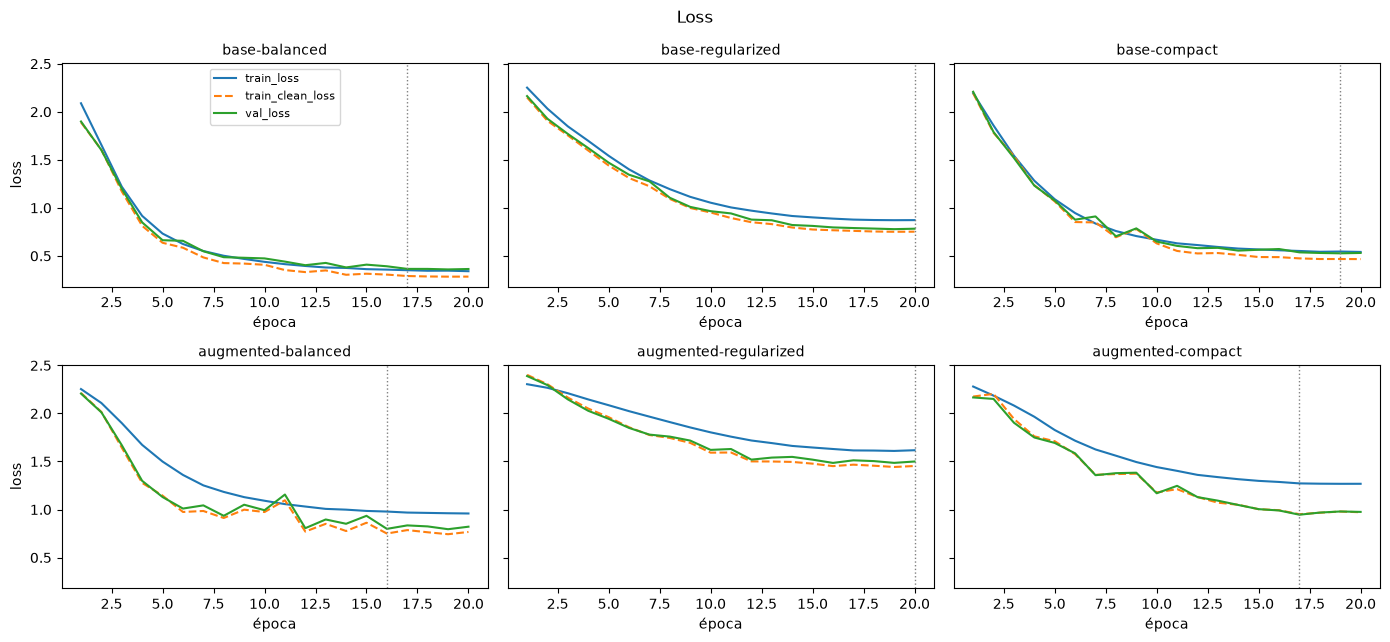

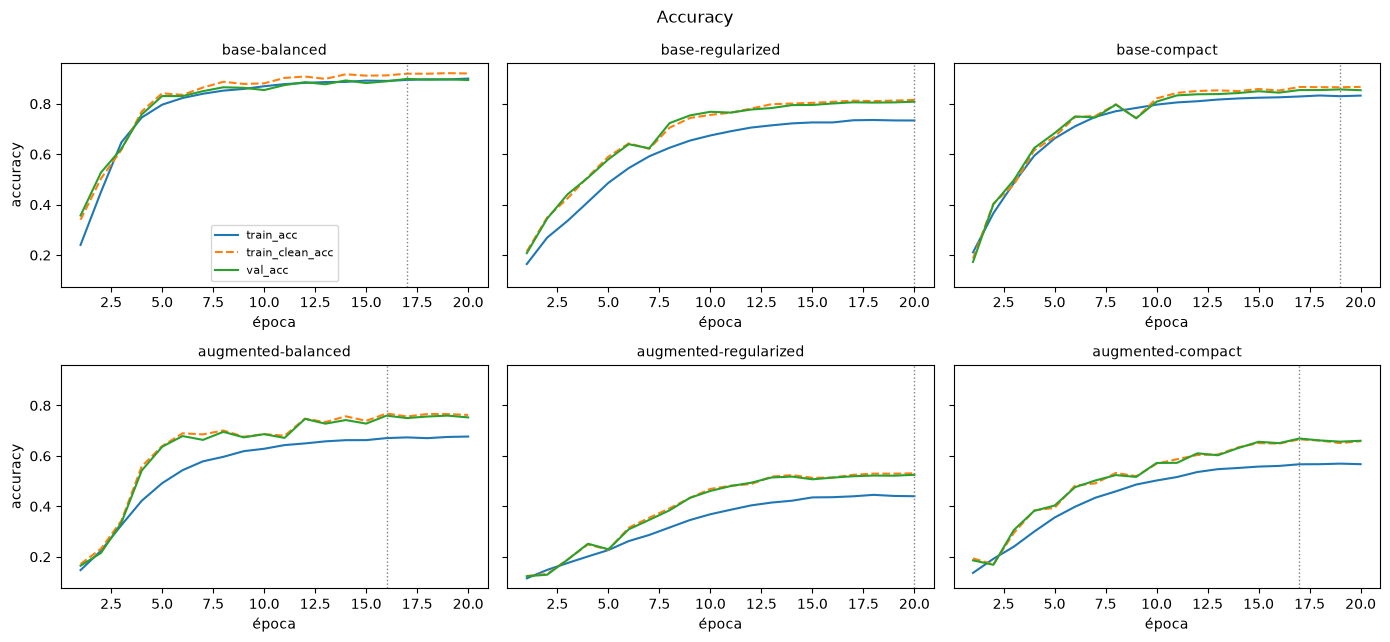

In [31]:
def plot_curves(rows, keys, title, ylabel):
    fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True)
    for ax, r in zip(axes.ravel(), rows):
        ep = [h["epoch"] for h in r["history"]]
        for k, style in keys:
            ax.plot(ep, [h[k] for h in r["history"]], style, label=k)
        ax.axvline(r["best_epoch"], color="gray", ls=":", lw=1); ax.set_title(r["run_name"].replace("model-b-", ""), fontsize=10); ax.set_xlabel("época")
    for ax in axes.ravel()[len(rows):]: ax.set_visible(False)
    axes[0, 0].set_ylabel(ylabel); axes[1, 0].set_ylabel(ylabel); axes[0, 0].legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_curves(ROWS, [("train_loss", "-"), ("train_clean_loss", "--"), ("val_loss", "-")], "Loss", "loss")
plot_curves(ROWS, [("train_acc", "-"), ("train_clean_acc", "--"), ("val_acc", "-")], "Accuracy", "accuracy")

### Selección del mejor Modelo B

Se elige por **val F1** (el test no se usa para decidir) y se reporta su desempeño en test. Interpretación del gap (`train_clean_acc − val_acc`): un gap grande y positivo sugiere overfitting; accuracy baja en train y val a la vez sugiere underfitting.

Mejor Modelo B (por val F1): model-b-base-balanced
  val F1=0.8990 | TEST acc=0.8996 f1=0.8993 | gap=+0.0207 | params=31,370


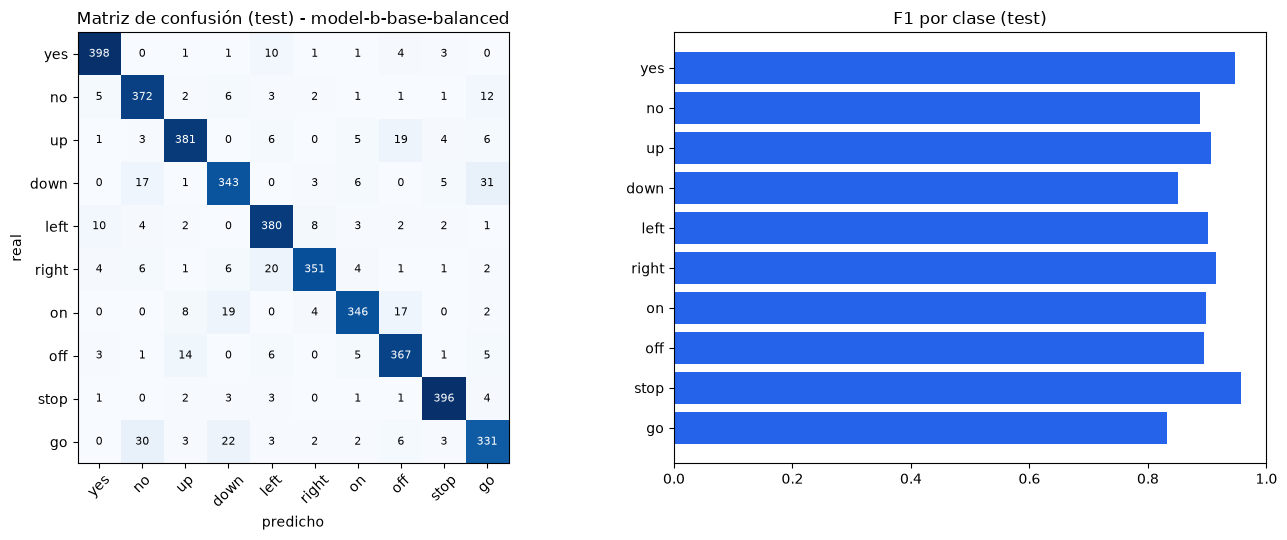

In [32]:
best = max(ROWS, key=lambda r: r["best_val_f1"])
print(f"Mejor Modelo B (por val F1): {best['run_name']}")
print(f"  val F1={best['best_val_f1']:.4f} | TEST acc={best['test_acc']:.4f} f1={best['test_f1']:.4f} | gap={best['gap_acc']:+.4f} | params={best['parameters']:,}")

cm = np.array(best["cm"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].imshow(cm, cmap="Blues"); axes[0].set_xticks(range(10), LABELS, rotation=45); axes[0].set_yticks(range(10), LABELS)
for i in range(10):
    for j in range(10):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[0].set_xlabel("predicho"); axes[0].set_ylabel("real"); axes[0].set_title(f"Matriz de confusión (test) - {best['run_name']}")
axes[1].barh(LABELS, [best["f1_per_class"][l] for l in LABELS], color="#2563eb"); axes[1].invert_yaxis()
axes[1].set_xlim(0, 1); axes[1].set_title("F1 por clase (test)"); plt.tight_layout(); plt.show()

## 8. Exportación a ONNX y verificación

Se exporta el mejor modelo, se valida el grafo con `onnx.checker`, se comprueban entradas/salidas y se compara PyTorch vs. ONNX Runtime con muestras reales de test (batch 1 y batch >1). También se escribe `preprocessing.json` con el pipeline exacto que debe replicar la app.

In [ ]:
import onnx, onnxruntime as ort

ckpt = torch.load(best["checkpoint"], map_location="cpu")
cfg = ckpt["config"]
model = MobileNetStyleCNN(cfg["num_classes"], cfg["width_mult"], dropout=cfg["dropout"])
model.load_state_dict(ckpt["model_state_dict"]); model.eval()

test_ds = CachedSpecs(CACHE, TEST_IDX)
X = torch.stack([test_ds[i][0] for i in range(min(20, len(test_ds)))])           # (N, 1, 64, 101)

ONNX_PATH = WORK_DIR / "model_b_best.onnx"
export_kwargs = dict(export_params=True, opset_version=17, do_constant_folding=True, input_names=["input"], output_names=["logits"],
                     dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}})
try:
    torch.onnx.export(model, X[:1], str(ONNX_PATH), dynamo=False, **export_kwargs)   # exportador clásico (TorchScript)
except TypeError:
    torch.onnx.export(model, X[:1], str(ONNX_PATH), **export_kwargs)               # PyTorch antiguo sin el argumento dynamo

onnx.checker.check_model(onnx.load(str(ONNX_PATH)))
sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
print("entrada:", sess.get_inputs()[0].name, sess.get_inputs()[0].shape, "| salida:", sess.get_outputs()[0].name, sess.get_outputs()[0].shape)

with torch.no_grad():
    ref = model(X).numpy()
out_batch = sess.run(["logits"], {"input": X.numpy()})[0]
np.testing.assert_allclose(ref, out_batch, rtol=1e-3, atol=1e-4)
for i in range(min(5, len(X))):
    np.testing.assert_allclose(ref[i:i + 1], sess.run(["logits"], {"input": X[i:i + 1].numpy()})[0], rtol=1e-3, atol=1e-4)
print(f"PyTorch == ONNX Runtime en {len(X)} muestras (batch y batch=1) | max |diff| = {np.abs(ref - out_batch).max():.2e}")
print("predicciones iguales:", bool((ref.argmax(1) == out_batch.argmax(1)).all()))

mel = make_mel()
pre = {"sample_rate": SAMPLE_RATE, "clip_samples": CLIP_SAMPLES, "channels": 1, "pad": "zeros al final / recorte a 1 s",
       "mel": {"n_fft": 400, "win_length": 400, "hop_length": 160, "n_mels": N_MELS, "power": mel.spectrogram.power,
               "center": mel.spectrogram.center, "pad_mode": mel.spectrogram.pad_mode, "f_min": 0.0,
               "f_max": SAMPLE_RATE / 2, "mel_scale": "htk", "norm": None},   # valores por defecto de torchaudio.MelSpectrogram
       "to_db": {"formula": "10*log10(max(x, amin))", "amin": 1e-10},
       "normalization": ckpt["normalization"], "input_shape": [1, 1, N_MELS, 101], "labels": ckpt["labels"], "output": "logits (aplicar softmax/argmax)"}
(WORK_DIR / "preprocessing.json").write_text(json.dumps(pre, indent=2))
print(json.dumps(pre, indent=2))

**Archivos para la app móvil:** `model_b_best.onnx` y `preprocessing.json` (en `WORK_DIR`). La app debe reproducir exactamente el mismo preprocesamiento: mono 16 kHz, 1 s, mel con `center=True` y relleno reflect, conversión a dB, normalización con `mean`/`std` y tensor `(1, 1, 64, 101)`.